In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42)
random.seed(42)
print("Seed: 42")

Seed: 42


In [3]:
import kagglehub
import pandas as pd
import os

# --- 1. TẢI DỮ LIỆU TỰ ĐỘNG ---

try:
    path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    DATA_PATH = os.path.join(path, csv_files[0])
except:
    DATA_PATH = 'heart.csv' # Fallback nếu tải lỗi

# --- 2. ĐỊNH NGHĨA CỘT  ---

numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope'] 
# (fbs là FastingBS, slope là ST_Slope)

K_features = 10

# --- 3. ĐỌC VÀ XỬ LÝ ---

raw = pd.read_csv(DATA_PATH) 


raw = raw.rename(columns={
    'Age': 'age', 
    'Sex': 'sex', 
    'ChestPainType': 'cp',
    'RestingBP': 'trestbps', 
    'Cholesterol': 'chol',
    'FastingBS': 'fbs', 
    'RestingECG': 'restecg', 
    'MaxHR': 'thalach', 
    'ExerciseAngina': 'exang', 
    'Oldpeak': 'oldpeak', 
    'ST_Slope': 'slope', 
    'HeartDisease': 'target'
})

# SỬA LỖI 3: Xử lý sơ bộ dữ liệu dạng chữ (String) sang số 

mapping_sex = {'M': 1, 'F': 0}
mapping_exang = {'Y': 1, 'N': 0}

raw['sex'] = raw['sex'].map(mapping_sex)
raw['exang'] = raw['exang'].map(mapping_exang)

# Chuyển đổi các cột số 
for c in numeric_cols:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')


raw['target'] = raw['target'].astype(int)


print("Shape:", raw.shape)
display(raw.head())
print("\nKiểm tra giá trị thiếu:")
display(raw.isna().sum())

Shape: (918, 12)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0



Kiểm tra giá trị thiếu:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
target      0
dtype: int64

In [4]:

raw = pd.get_dummies(raw, columns=['cp', 'restecg', 'slope'], drop_first=True)

print("Shape mới sau khi mã hóa:", raw.shape)
display(raw.head())

Shape mới sau khi mã hóa: (918, 16)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,cp_ATA,cp_NAP,cp_TA,restecg_Normal,restecg_ST,slope_Flat,slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler


TARGET = 'target'


raw_feature_cols = [c for c in raw.columns if c != TARGET]
X_all = raw[raw_feature_cols]
y_all = raw[TARGET]


numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Danh sách các cột phân loại (Categorical/Binary)

categorical_cols = [c for c in raw_feature_cols if c not in numeric_cols]

print("Số lượng cột số:", len(numeric_cols))
print("Số lượng cột phân loại (One-hot/Binary):", len(categorical_cols))



X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


# ---  XÂY DỰNG PIPELINE ---

cat_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('scaler', MinMaxScaler()) 
])


num_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


preprocess = ColumnTransformer([
    ('num', num_proc, numeric_cols),
    ('cat', cat_proc, categorical_cols),
])

raw_pipeline = Pipeline([
    ('preprocess', preprocess),
])


# --- TRANSFORM ---
# Fit trên tập Train, Transform trên Val và Test để tránh Data Leakage
X_raw_train = raw_pipeline.fit_transform(X_train, y_train)
X_raw_val = raw_pipeline.transform(X_val)
X_raw_test = raw_pipeline.transform(X_test)

print("\nKích thước sau pipeline:")
print("Train:", X_raw_train.shape)
print("Val  :", X_raw_val.shape)
print("Test :", X_raw_test.shape)

Số lượng cột số: 5
Số lượng cột phân loại (One-hot/Binary): 10

Kích thước sau pipeline:
Train: (734, 15)
Val  : (92, 15)
Test : (92, 15)


In [6]:
preprocessed_feature_names = []
for name, transformer, columns in preprocess.transformers_:
    if hasattr(transformer, 'get_feature_names_out'):
        preprocessed_feature_names.extend(transformer.get_feature_names_out(columns))
    else:
        preprocessed_feature_names.extend(columns)

X_raw_train_df = pd.DataFrame(
    X_raw_train, columns=preprocessed_feature_names, index=X_train.index)
X_raw_val_df = pd.DataFrame(
    X_raw_val, columns=preprocessed_feature_names, index=X_val.index)
X_raw_test_df = pd.DataFrame(
    X_raw_test, columns=preprocessed_feature_names, index=X_test.index)

out_dir = Path('splits'); out_dir.mkdir(parents=True, exist_ok=True)
pd.concat([X_raw_train_df, y_train.rename(TARGET)],
          axis=1).to_csv(out_dir / 'raw_train.csv', index=False)
pd.concat([X_raw_val_df, y_val.rename(TARGET)],
          axis=1).to_csv(out_dir / 'raw_val.csv', index=False)
pd.concat([X_raw_test_df, y_test.rename(TARGET)],
          axis=1).to_csv(out_dir / 'raw_test.csv', index=False)

display(X_raw_train_df)

,age,trestbps,chol,thalach,oldpeak,sex,fbs,exang,cp_ATA,cp_NAP,cp_TA,restecg_Normal,restecg_ST,slope_Flat,slope_Up
485,0.970012,0.339016,0.127137,-0.324520,0.317046,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
486,0.122028,-1.266031,0.099443,1.689837,-0.440356,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
117,0.546020,-0.159102,1.244113,-0.247045,0.601071,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
361,-0.725956,1.501291,-1.876035,-0.479470,-0.819056,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
296,-0.407962,0.671094,-1.876035,0.101594,-0.156330,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,-0.301964,0.117630,-0.399042,0.527708,1.074447,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
201,-0.831954,-0.712567,0.247142,0.527708,-0.819056,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
462,0.546020,-0.601874,0.274836,-0.750634,0.411721,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
252,0.758016,-0.435834,0.819477,-0.828109,-0.819056,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [7]:
dt_feature_selection_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('decision_tree', DecisionTreeClassifier(random_state=42))
])

In [8]:
dt_feature_selection_pipeline.fit(X_train, y_train)
feature_importance_series = pd.Series(
    dt_feature_selection_pipeline.named_steps['decision_tree'].feature_importances_,
    index=preprocessed_feature_names
)
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

print("Sorted Feature Importances:")
display(sorted_feature_importances)

Sorted Feature Importances:


slope_Up          0.421219
chol              0.135043
thalach           0.094785
age               0.077335
oldpeak           0.058456
trestbps          0.056579
exang             0.034192
cp_NAP            0.029190
sex               0.027538
fbs               0.021612
cp_TA             0.013247
cp_ATA            0.011146
slope_Flat        0.007594
restecg_Normal    0.007165
restecg_ST        0.004899
dtype: float64

In [9]:
selected_features = sorted_feature_importances.head(K_features).index.tolist()
print(f"Top {K_features} selected features:")
print(selected_features)

Top 10 selected features:
['slope_Up', 'chol', 'thalach', 'age', 'oldpeak', 'trestbps', 'exang', 'cp_NAP', 'sex', 'fbs']


In [10]:
X_dt_train = X_raw_train_df[selected_features]
X_dt_val = X_raw_val_df[selected_features]
X_dt_test = X_raw_test_df[selected_features]

print("Head of X_dt_train:")
display(X_dt_train.head())
print("\nShape of X_dt_train:", X_dt_train.shape)

Head of X_dt_train:


,slope_Up,chol,thalach,age,oldpeak,trestbps,exang,cp_NAP,sex,fbs
485,0.0,0.127137,-0.324520,0.970012,0.317046,0.339016,1.0,0.0,1.0,1.0
486,1.0,0.099443,1.689837,0.122028,-0.440356,-1.266031,0.0,0.0,1.0,1.0
117,0.0,1.244113,-0.247045,0.546020,0.601071,-0.159102,1.0,0.0,0.0,1.0
361,0.0,-1.876035,-0.479470,-0.725956,-0.819056,1.501291,1.0,0.0,1.0,0.0
296,0.0,-1.876035,0.101594,-0.407962,-0.156330,0.671094,1.0,0.0,1.0,1.0



Shape of X_dt_train: (734, 10)


In [11]:
pd.concat([X_dt_train, y_train.rename(TARGET)],
          axis=1).to_csv(out_dir / 'dt_train.csv', index=False)
pd.concat([X_dt_val, y_val.rename(TARGET)],
          axis=1).to_csv(out_dir / 'dt_val.csv', index=False)
pd.concat([X_dt_test, y_test.rename(TARGET)],
          axis=1).to_csv(out_dir / 'dt_test.csv', index=False)

print(f"Saved RAW_DT splits. K (RAW_DT features) = {K_features}")
X_dt_train

Saved RAW_DT splits. K (RAW_DT features) = 10


,slope_Up,chol,thalach,age,oldpeak,trestbps,exang,cp_NAP,sex,fbs
485,0.0,0.127137,-0.324520,0.970012,0.317046,0.339016,1.0,0.0,1.0,1.0
486,1.0,0.099443,1.689837,0.122028,-0.440356,-1.266031,0.0,0.0,1.0,1.0
117,0.0,1.244113,-0.247045,0.546020,0.601071,-0.159102,1.0,0.0,0.0,1.0
361,0.0,-1.876035,-0.479470,-0.725956,-0.819056,1.501291,1.0,0.0,1.0,0.0
296,0.0,-1.876035,0.101594,-0.407962,-0.156330,0.671094,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
276,0.0,-0.399042,0.527708,-0.301964,1.074447,0.117630,0.0,1.0,1.0,0.0
201,1.0,0.247142,0.527708,-0.831954,-0.819056,-0.712567,0.0,1.0,1.0,0.0
462,0.0,0.274836,-0.750634,0.546020,0.411721,-0.601874,1.0,0.0,1.0,0.0
252,1.0,0.819477,-0.828109,0.758016,-0.819056,-0.435834,1.0,0.0,1.0,0.0


Feature Engineering

In [12]:
def add_new_features_func(df):
    df = df.copy()
    if {'chol','age'} <= set(df.columns):
        df['chol_per_age'] = df['chol']/df['age']
    if {'trestbps','age'} <= set(df.columns):
        df['bps_per_age'] = df['trestbps']/df['age']
    if {'thalach','age'} <= set(df.columns):
        df['hr_ratio'] = df['thalach']/df['age']
    if 'age' in df.columns:
        df['age_bin'] = pd.cut(
            df['age'], bins=5, labels=False
        ).astype('category')
    return df

gen_num = ['chol_per_age','bps_per_age','hr_ratio']
gen_cat = ['age_bin']
all_nums = [c for c in numeric_cols] + gen_num
all_cats = [c for c in categorical_cols] + gen_cat

class AddNewFeaturesTransformer(
    BaseEstimator,
    TransformerMixin
):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.columns_ = X.columns
        self.new_features_ = []
        if {'chol','age'} <= set(X.columns):
             self.new_features_.append('chol_per_age')
        if {'trestbps','age'} <= set(X.columns):
             self.new_features_.append('bps_per_age')
        if {'thalach','age'} <= set(X.columns):
             self.new_features_.append('hr_ratio')
        if 'age' in X.columns:
             self.new_features_.append('age_bin')
        return self

    def transform(self, X):
        return add_new_features_func(X)

    def get_feature_names_out(self, input_features=None):
        return list(self.columns_) + self.new_features_


num_proc = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc',  StandardScaler())])
cat_proc = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('ohe', OneHotEncoder(handle_unknown='ignore',
                                           sparse_output=False))])
pre = ColumnTransformer([
    ('num', num_proc, all_nums),
    ('cat', cat_proc, all_cats),
], verbose_feature_names_out=False).set_output(transform='pandas')

fe_pre = Pipeline([
    ('add', AddNewFeaturesTransformer()),
    ('pre', pre),
]).set_output(transform='pandas')

Xt_tr = fe_pre.fit_transform(X_train, y_train)
Xt_va = fe_pre.transform(X_val)
Xt_te = fe_pre.transform(X_test)

nz_cols = Xt_tr.columns[Xt_tr.nunique(dropna=False) > 1]
Xt_tr = Xt_tr[nz_cols]
Xt_va = Xt_va[nz_cols]
Xt_te = Xt_te[nz_cols]

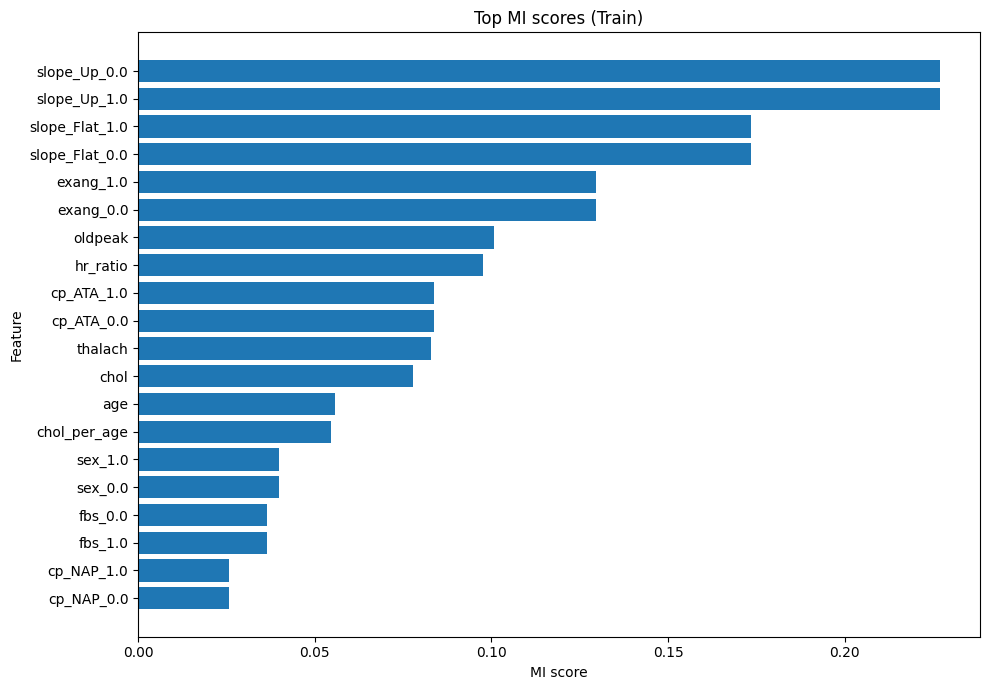

0       slope_Up_0.0
1       slope_Up_1.0
2     slope_Flat_1.0
3     slope_Flat_0.0
4          exang_1.0
5          exang_0.0
6            oldpeak
7           hr_ratio
8         cp_ATA_1.0
9         cp_ATA_0.0
10           thalach
11              chol
12               age
13      chol_per_age
14           sex_1.0
Name: fe_topk_features, dtype: object

In [13]:
ohe = fe_pre.named_steps['pre'].named_transformers_['cat'].named_steps['ohe']
cat_names = list(ohe.get_feature_names_out(all_cats))
is_discrete = np.array(
    [c in cat_names for c in Xt_tr.columns],
    dtype=bool
)
mi = mutual_info_classif(Xt_tr.values, y_train.values,
                         discrete_features=is_discrete,
                         random_state=42)
mi_series = pd.Series(
    mi, index=Xt_tr.columns).sort_values(ascending=False)

N = min(20, len(mi_series))
topN = mi_series.head(N).iloc[::-1]
plt.figure(figsize=(10, max(6, 0.35*N)))
plt.barh(topN.index, topN.values)
plt.title('Top MI scores (Train)')
plt.xlabel('MI score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('top_mi_scores.pdf', bbox_inches='tight')
plt.show()

K = raw.columns.drop('target').shape[0]
topk_cols = list(mi_series.head(K).index)

fe_tr = Xt_tr[topk_cols].assign(target=y_train.values)
fe_va = Xt_va[topk_cols].assign(target=y_val.values)
fe_te = Xt_te[topk_cols].assign(target=y_test.values)

out = Path('splits'); out.mkdir(parents=True, exist_ok=True)
fe_tr.to_csv(out/'fe_train.csv', index=False)
fe_va.to_csv(out/'fe_val.csv', index=False)
fe_te.to_csv(out/'fe_test.csv', index=False)

display(pd.Series(
    topk_cols, name='fe_topk_features'
).reset_index(drop=True))

In [14]:
display(fe_tr.head())

,slope_Up_0.0,slope_Up_1.0,slope_Flat_1.0,slope_Flat_0.0,exang_1.0,exang_0.0,oldpeak,hr_ratio,cp_ATA_1.0,cp_ATA_0.0,thalach,chol,age,chol_per_age,sex_1.0,target
485,1.0,0.0,1.0,0.0,1.0,0.0,0.317046,-0.708930,1.0,0.0,-0.324520,0.127137,0.970012,-0.220020,1.0,1
486,0.0,1.0,0.0,1.0,0.0,1.0,-0.440356,0.690330,1.0,0.0,1.689837,0.099443,0.122028,-0.023516,1.0,0
117,1.0,0.0,1.0,0.0,1.0,0.0,0.601071,-0.515395,0.0,1.0,-0.247045,1.244113,0.546020,0.785408,0.0,1
361,1.0,0.0,1.0,0.0,1.0,0.0,-0.819056,-0.025017,0.0,1.0,-0.479470,-1.876035,-0.725956,-1.736036,1.0,1
296,1.0,0.0,1.0,0.0,1.0,0.0,-0.156330,0.134758,0.0,1.0,0.101594,-1.876035,-0.407962,-1.736036,1.0,1


Decision Tree on Feature Engineering Dataset

In [15]:
dt_fe_feature_selection_pipeline = Pipeline([
    ('preprocess', fe_pre),
    ('decision_tree', DecisionTreeClassifier(random_state=42))
])

In [16]:
dt_fe_feature_selection_pipeline.fit(X_train, y_train)
pipeline_feature_names = dt_fe_feature_selection_pipeline.named_steps['preprocess'].get_feature_names_out()
feature_importance_series = pd.Series(
    dt_fe_feature_selection_pipeline.named_steps['decision_tree'].feature_importances_,
    index=pipeline_feature_names
)
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)
print("Sorted Feature Importances:")
display(sorted_feature_importances)

Sorted Feature Importances:


slope_Up_0.0          0.421219
chol                  0.083177
bps_per_age           0.077294
thalach               0.074543
oldpeak               0.051100
hr_ratio              0.046858
age                   0.038118
chol_per_age          0.030880
trestbps              0.028132
fbs_0.0               0.024658
sex_0.0               0.023446
exang_0.0             0.022798
cp_NAP_1.0            0.022746
cp_TA_0.0             0.012398
cp_NAP_0.0            0.009328
cp_ATA_1.0            0.007781
age_bin_2.0           0.006625
restecg_Normal_0.0    0.004199
restecg_Normal_1.0    0.004134
fbs_1.0               0.004134
age_bin_0.0           0.003675
cp_ATA_0.0            0.002756
sex_1.0               0.000000
exang_1.0             0.000000
cp_TA_1.0             0.000000
slope_Flat_0.0        0.000000
restecg_ST_1.0        0.000000
restecg_ST_0.0        0.000000
slope_Flat_1.0        0.000000
slope_Up_1.0          0.000000
age_bin_1.0           0.000000
age_bin_3.0           0.000000
age_bin_

In [17]:
selected_features = sorted_feature_importances.head(K_features).index.tolist()
print(f"Top {K_features} selected features:")
print(selected_features)

Top 10 selected features:
['slope_Up_0.0', 'chol', 'bps_per_age', 'thalach', 'oldpeak', 'hr_ratio', 'age', 'chol_per_age', 'trestbps', 'fbs_0.0']


In [18]:
X_fe_dt_train = Xt_tr[selected_features]
X_fe_dt_val = Xt_va[selected_features]
X_fe_dt_test = Xt_te[selected_features]

print("Head of X_fe_dt_train:")
display(X_fe_dt_train.head())
print("\nShape of X_fe_dt_train:", X_fe_dt_train.shape)

Head of X_fe_dt_train:


,slope_Up_0.0,chol,bps_per_age,thalach,oldpeak,hr_ratio,age,chol_per_age,trestbps,fbs_0.0
485,1.0,0.127137,-0.626315,-0.324520,0.317046,-0.708930,0.970012,-0.220020,0.339016,0.0
486,0.0,0.099443,-1.018093,1.689837,-0.440356,0.690330,0.122028,-0.023516,-1.266031,0.0
117,1.0,1.244113,-0.631933,-0.247045,0.601071,-0.515395,0.546020,0.785408,-0.159102,0.0
361,1.0,-1.876035,1.648053,-0.479470,-0.819056,-0.025017,-0.725956,-1.736036,1.501291,1.0
296,1.0,-1.876035,0.690664,0.101594,-0.156330,0.134758,-0.407962,-1.736036,0.671094,0.0



Shape of X_fe_dt_train: (734, 10)


In [19]:
pd.concat([X_fe_dt_train, y_train.rename(TARGET)],
          axis=1).to_csv(out_dir / 'fe_dt_train.csv', index=False)
pd.concat([X_fe_dt_val, y_val.rename(TARGET)],
          axis=1).to_csv(out_dir / 'fe_dt_val.csv', index=False)
pd.concat([X_fe_dt_test, y_test.rename(TARGET)],
          axis=1).to_csv(out_dir / 'fe_dt_test.csv', index=False)

print(f"Saved FE_DT splits. K (FE features) = {K_features}")

Saved FE_DT splits. K (FE features) = 10


In [20]:
X_fe_dt_train

,slope_Up_0.0,chol,bps_per_age,thalach,oldpeak,hr_ratio,age,chol_per_age,trestbps,fbs_0.0
485,1.0,0.127137,-0.626315,-0.324520,0.317046,-0.708930,0.970012,-0.220020,0.339016,0.0
486,0.0,0.099443,-1.018093,1.689837,-0.440356,0.690330,0.122028,-0.023516,-1.266031,0.0
117,1.0,1.244113,-0.631933,-0.247045,0.601071,-0.515395,0.546020,0.785408,-0.159102,0.0
361,1.0,-1.876035,1.648053,-0.479470,-0.819056,-0.025017,-0.725956,-1.736036,1.501291,1.0
296,1.0,-1.876035,0.690664,0.101594,-0.156330,0.134758,-0.407962,-1.736036,0.671094,0.0
...,...,...,...,...,...,...,...,...,...,...
276,1.0,-0.399042,0.210425,0.527708,1.074447,0.316492,-0.301964,-0.355224,0.117630,1.0
201,0.0,0.247142,0.137588,0.527708,-0.819056,0.676960,-0.831954,0.464632,-0.712567,1.0
462,1.0,0.274836,-0.889373,-0.750634,0.411721,-0.763836,0.546020,0.002119,-0.601874,1.0
252,0.0,0.819477,-0.924719,-0.828109,-0.819056,-0.874116,0.758016,0.370833,-0.435834,1.0


In [21]:
# zip folder
!zip -r dataset.zip splits

  adding: splits/ (stored 0%)
  adding: splits/fe_train.csv (deflated 77%)
  adding: splits/raw_train.csv (deflated 85%)
  adding: splits/raw_test.csv (deflated 76%)
  adding: splits/fe_dt_test.csv (deflated 66%)
  adding: splits/fe_dt_val.csv (deflated 65%)
  adding: splits/raw_val.csv (deflated 76%)
  adding: splits/fe_val.csv (deflated 70%)
  adding: splits/fe_test.csv (deflated 70%)
  adding: splits/dt_val.csv (deflated 73%)
  adding: splits/dt_train.csv (deflated 84%)
  adding: splits/fe_dt_train.csv (deflated 73%)
  adding: splits/dt_test.csv (deflated 74%)
